# Notebook: Data Analysis exam

SINGARIN-SOLÉ Livio

In [184]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# Dataset Describing

In [185]:
dataset_automobile = pd.read_csv("automobiles.csv")
dataset_automobile.head(10)

,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year,origin_country,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [186]:
dataset_automobile.describe()

,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year,origin_country
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


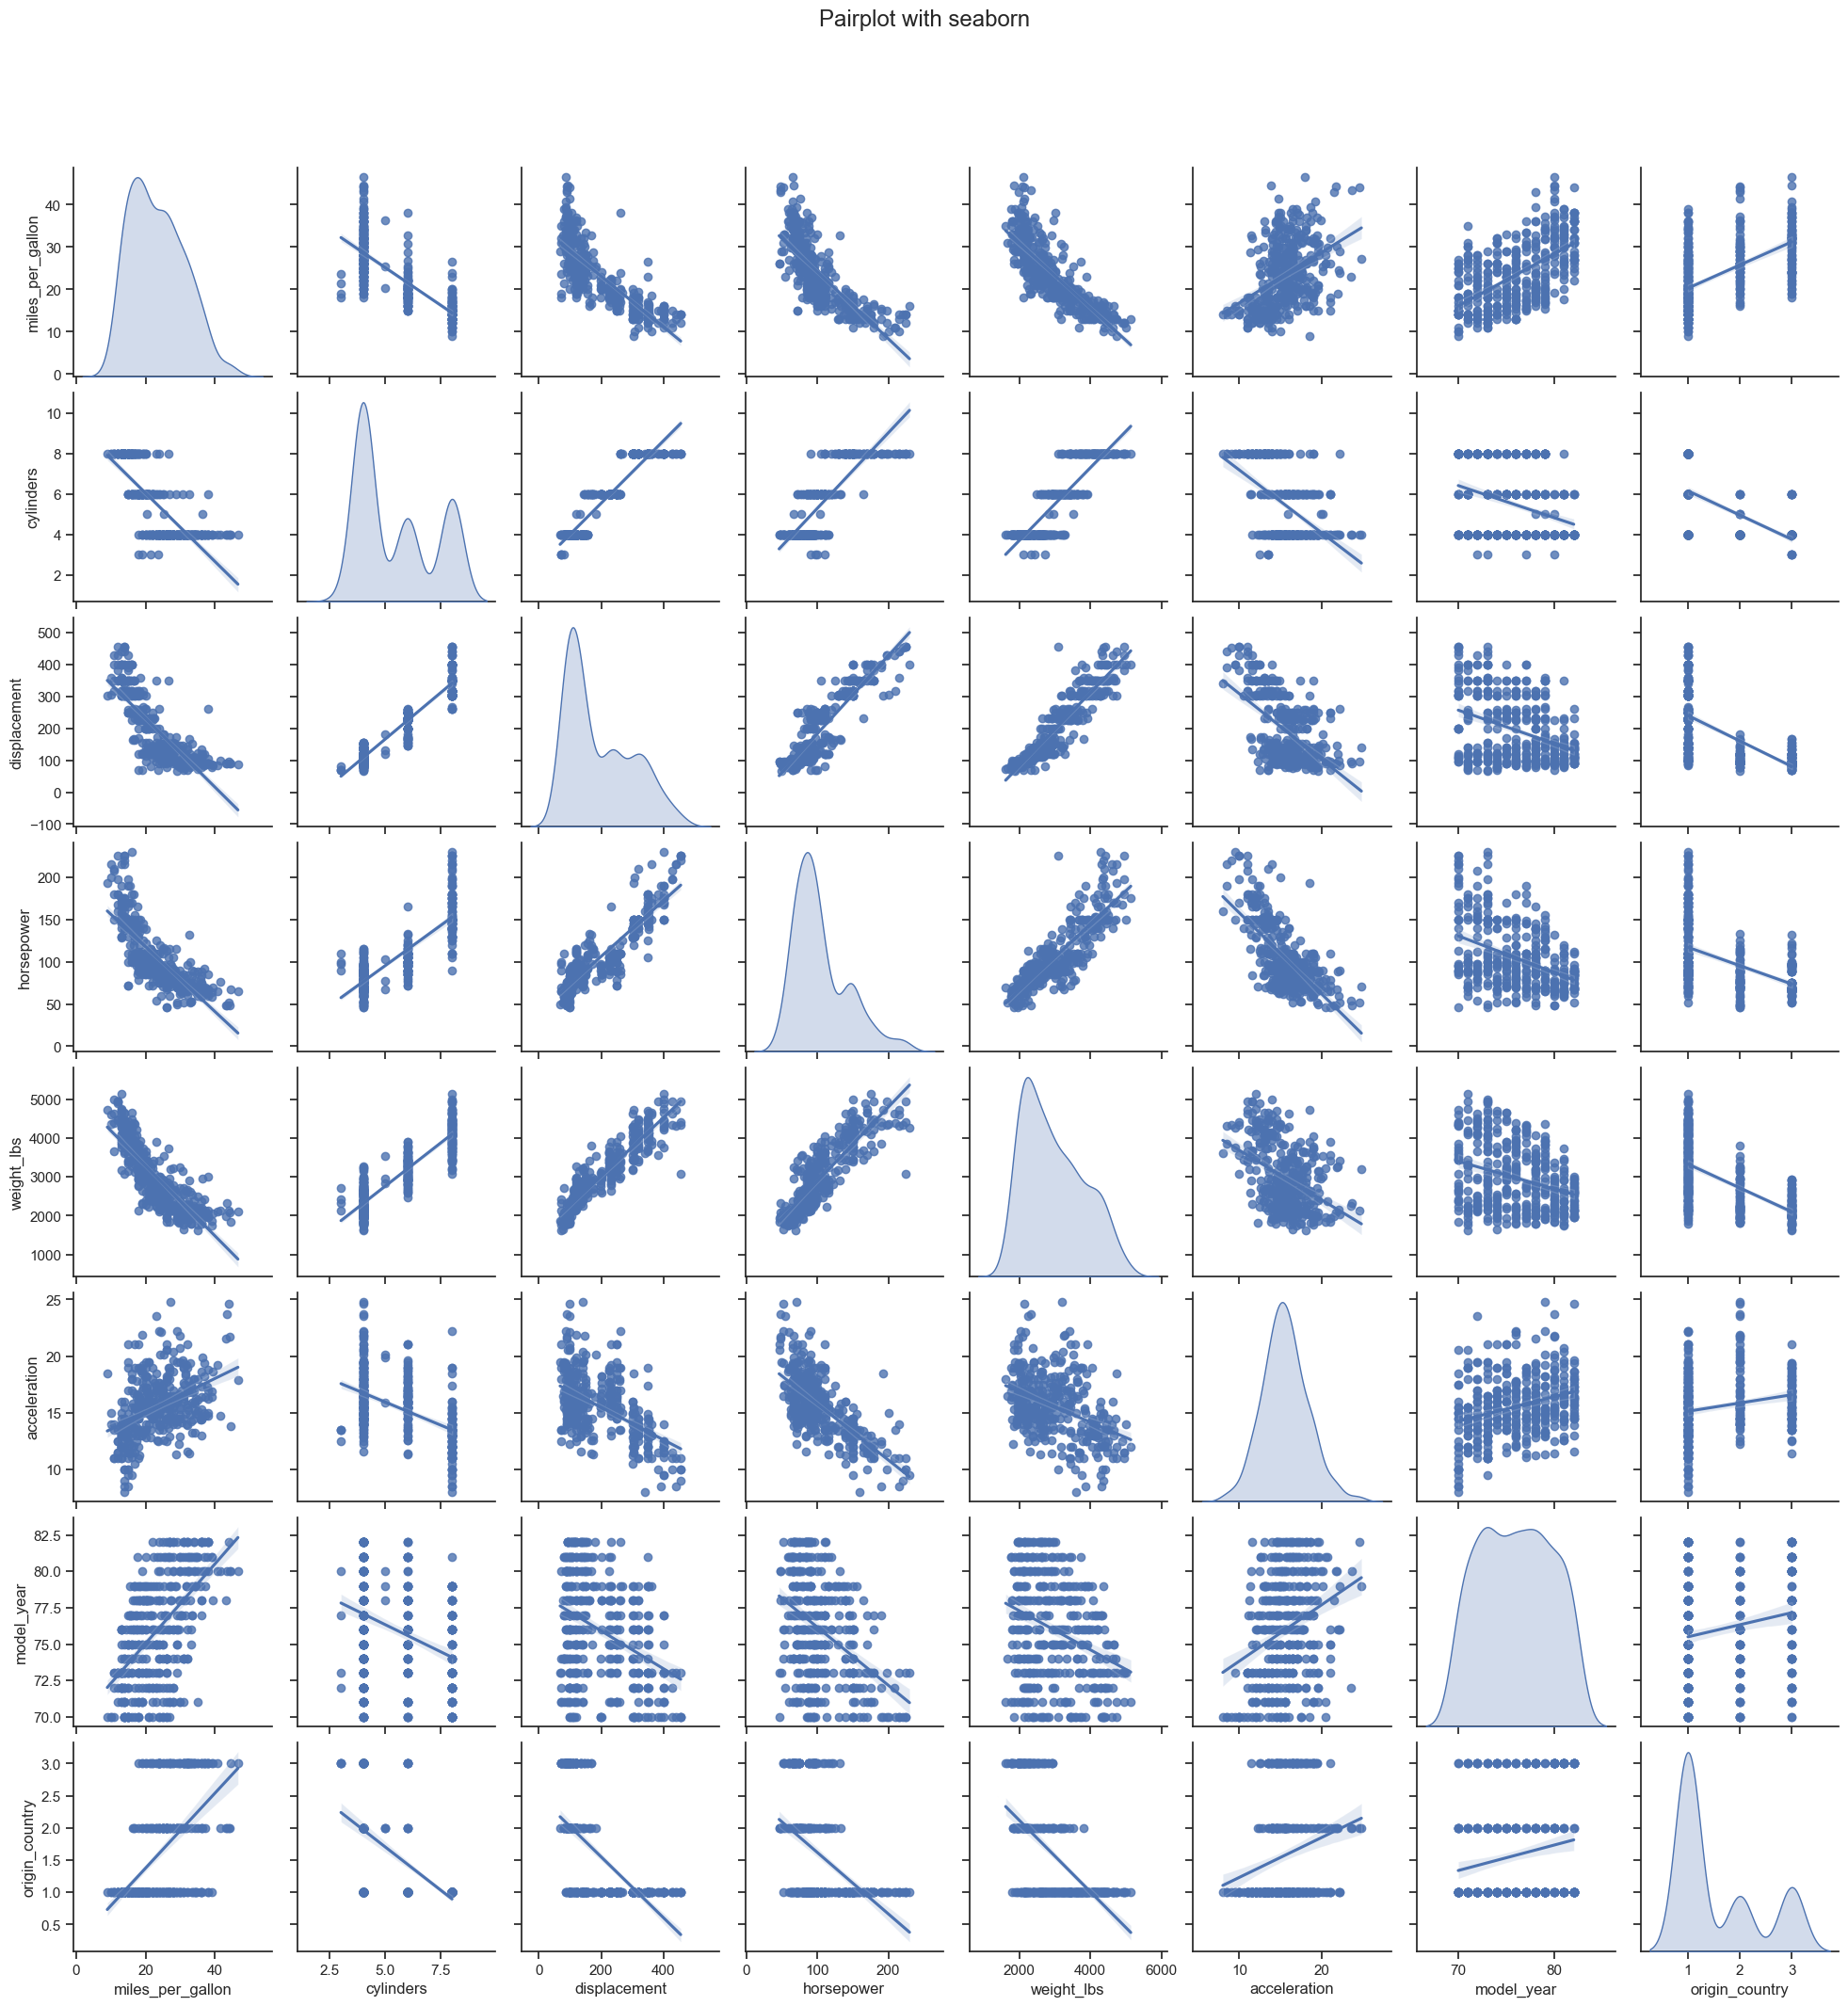

In [187]:
sns.set(style="ticks", color_codes=True)
g = sns.pairplot(dataset_automobile,diag_kind="kde", kind="reg")
g.fig.suptitle('Pairplot with seaborn', y=1.07, fontsize='x-large')
plt.show()

## Correlation Matrix

<Axes: >

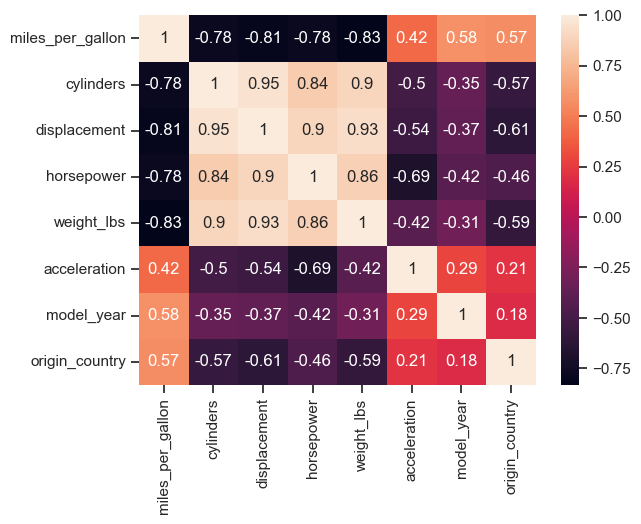

In [188]:
sns.heatmap(dataset_automobile.drop("car_name", axis=1).corr(), annot=True)

In [189]:
dataset_automobile.drop("car_name", axis=1).corr()

,miles_per_gallon,cylinders,displacement,horsepower,weight_lbs,acceleration,model_year,origin_country
miles_per_gallon,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight_lbs,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin_country,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


## Compare fuel efficiency across different origins (USA, Europe, Japan)

In [195]:
origin_map = {1: "USA", 2: "Europe", 3: "Japan"}

means = (
    dataset_automobile
    .groupby("origin_country")["miles_per_gallon"]
    .mean()
)

print("Average mpg:")
for code, avg in means.items():
    print(f"{origin_map.get(code, code)}: {avg}")


Average mpg:
USA: 20.0334693877551
Europe: 27.602941176470587
Japan: 30.450632911392404


# Distributions of the features

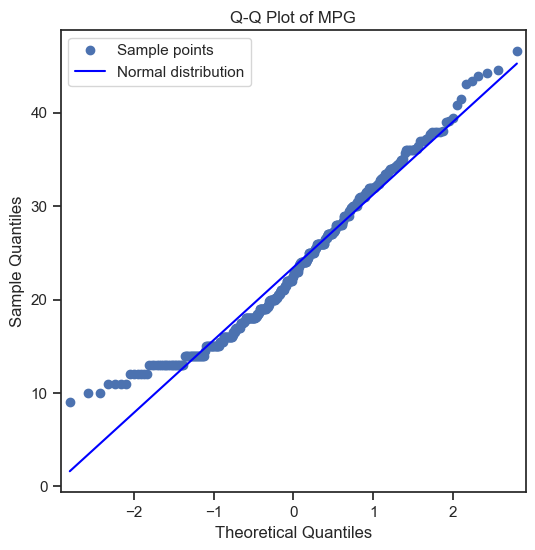

In [198]:
import statsmodels.api as sm

fig, ax = plt.subplots(figsize=(6, 6))

sm.qqplot(
    dataset_automobile["miles_per_gallon"],  
    line="s",
    ax=ax
)
lines = ax.get_lines()
if len(lines) > 1:
    lines[1].set_color("blue")

ax.legend(
    ["Sample points", "Normal distribution"],
    loc="best"
)

ax.set_title("Q-Q Plot of MPG")
plt.show()

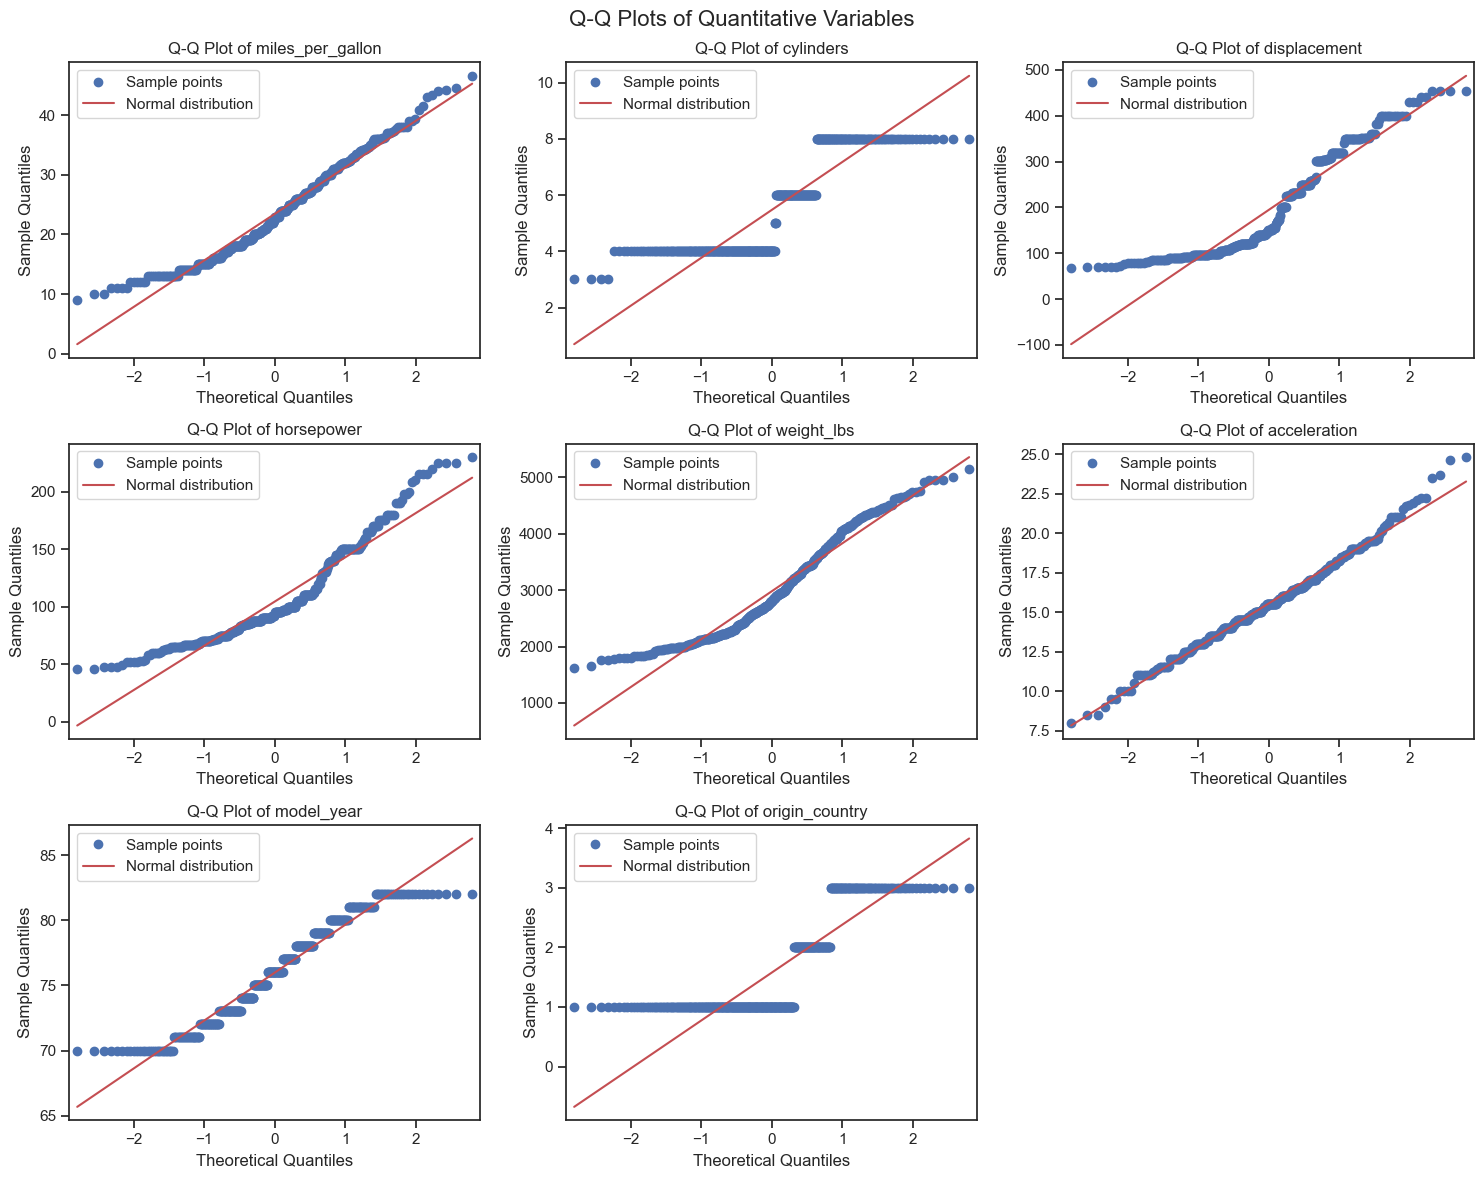

In [447]:
quantitative_vars = dataset_automobile.select_dtypes(
    include=["int64", "float64"]
).columns

n_vars = len(quantitative_vars)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, var in enumerate(quantitative_vars):
    sm.qqplot(
        dataset_automobile[var],
        line="s",
        ax=axes[i]
    )
    axes[i].set_title(f"Q-Q Plot of {var}")
    lines = axes[i].get_lines()
    lines[0].set_label("Sample points")
    lines[1].set_label("Normal distribution")
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Q-Q Plots of Quantitative Variables", fontsize=16)
plt.tight_layout()
plt.show()


In [201]:
from scipy import stats
import pandas as pd

quantitative_vars = dataset_automobile.select_dtypes(
    include=["int64", "float64"]
).columns

shapiro_results = []

for var in quantitative_vars:
    stat, p_value = stats.shapiro(dataset_automobile[var])
    shapiro_results.append({
        "Variable": var,
        "Shapiro statistic": stat,
        "p-value": p_value
    })

shapiro_df = pd.DataFrame(shapiro_results)

print(shapiro_df)

           Variable  Shapiro statistic       p-value
0  miles_per_gallon           0.967170  1.049441e-07
1         cylinders           0.750660  6.880242e-24
2      displacement           0.881836  8.983637e-17
3        horsepower           0.904097  5.022069e-15
4        weight_lbs           0.941466  2.601686e-11
5      acceleration           0.991867  3.052886e-02
6        model_year           0.946967  1.222617e-10
7    origin_country           0.673764  8.802044e-27


# Regression

## Univariate Regression

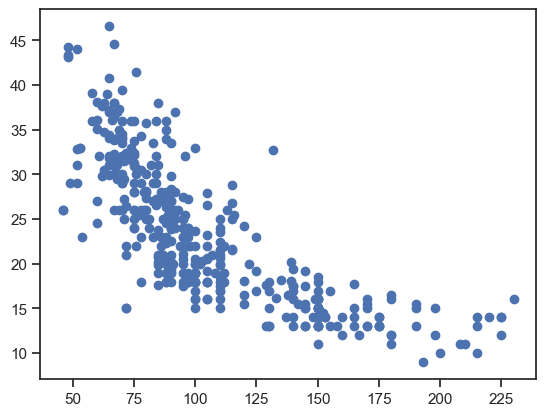

In [202]:
plt.figure("Miles per Gallon vs Horsepower")
plt.scatter(
    dataset_automobile["horsepower"],      # X
    dataset_automobile["miles_per_gallon"] # y
)

In [205]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Variables
hp = dataset_automobile["horsepower"].to_numpy()
mpg = dataset_automobile["miles_per_gallon"].to_numpy()

# Model 1
X_transformed = np.column_stack([hp, np.sqrt(hp)])

# Modèles 2 and 3 : horsepower only
X_simple = hp.reshape(-1, 1)

y = mpg

# Split
Xtr_t, Xte_t, ytr, yte = train_test_split(
    X_transformed, y, test_size=0.2, random_state=0
)

Xtr_s, Xte_s, _, _ = train_test_split(
    X_simple, y, test_size=0.2, random_state=0
)


In [206]:
lin_trans = LinearRegression()
lin_trans.fit(Xtr_t, ytr)
y_pred_lin_trans = lin_trans.predict(Xte_t)

In [207]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(Xtr_s, ytr)
y_pred_ridge = ridge.predict(Xte_s)

In [208]:
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(30,),
        max_iter=5000,
        random_state=1,
        early_stopping=True
    ))
])

mlp.fit(Xtr_s, ytr)
y_pred_mlp = mlp.predict(Xte_s)

In [211]:
results = {
    "Model": [
        "Linear + sqrt(horsepower)",
        "Ridge regression",
        "MLP regression"
    ],
    "RMSE": [
        mean_squared_error(yte, y_pred_lin_trans),
        mean_squared_error(yte, y_pred_ridge),
        mean_squared_error(yte, y_pred_mlp)
    ],
    "R²": [
        r2_score(yte, y_pred_lin_trans),
        r2_score(yte, y_pred_ridge),
        r2_score(yte, y_pred_mlp)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                       Model       RMSE        R²
0  Linear + sqrt(horsepower)  15.970125  0.743061
1           Ridge regression  22.022283  0.645689
2             MLP regression  16.700147  0.731316


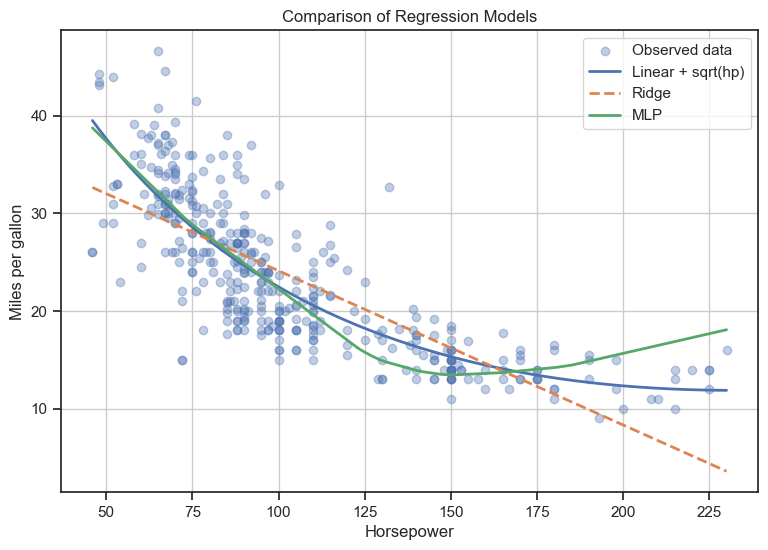

In [212]:
hp_grid = np.linspace(hp.min(), hp.max(), 300)

y_lin_curve = lin_trans.predict(
    np.column_stack([hp_grid, np.sqrt(hp_grid)])
)
y_ridge_curve = ridge.predict(hp_grid.reshape(-1, 1))
y_mlp_curve = mlp.predict(hp_grid.reshape(-1, 1))

plt.figure(figsize=(9, 6))

plt.scatter(
    hp, mpg,
    alpha=0.35,
    label="Observed data"
)

plt.plot(hp_grid, y_lin_curve, linewidth=2, label="Linear + sqrt(hp)")
plt.plot(hp_grid, y_ridge_curve, linestyle="--", linewidth=2, label="Ridge")
plt.plot(hp_grid, y_mlp_curve, linewidth=2, label="MLP")

plt.xlabel("Horsepower")
plt.ylabel("Miles per gallon")
plt.title("Comparison of Regression Models")
plt.legend()
plt.grid(True)
plt.show()


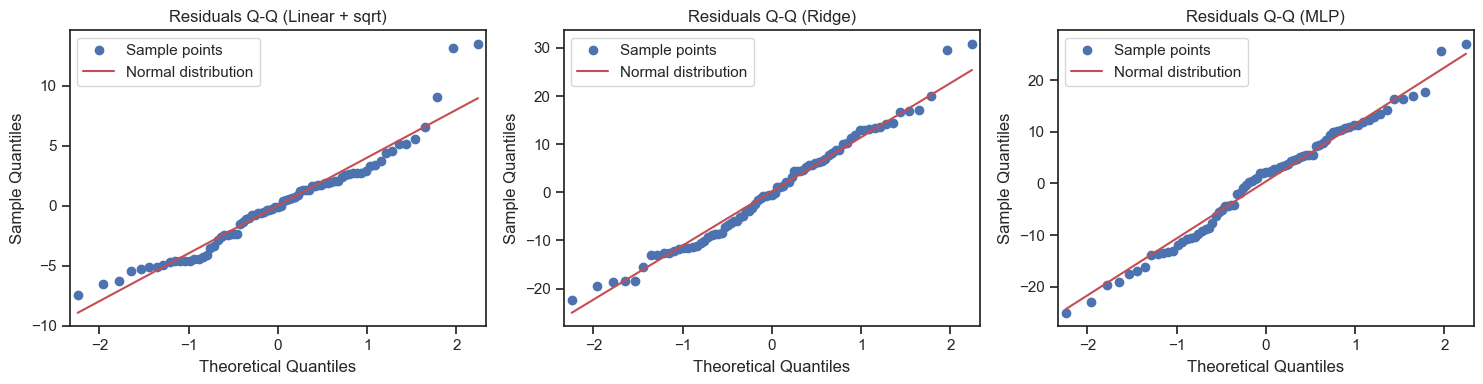

In [446]:
res_lin = yte - y_pred_lin_trans
res_ridge = yte - y_pred_ridge
res_mlp = yte - y_pred_mlp

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sm.qqplot(res_lin, line="s", ax=axes[0])
axes[0].set_title("Residuals Q-Q (Linear + sqrt)")
lines = axes[0].get_lines()
lines[0].set_label("Sample points")
lines[1].set_label("Normal distribution")
axes[0].legend()

sm.qqplot(res_ridge, line="s", ax=axes[1])
axes[1].set_title("Residuals Q-Q (Ridge)")
lines = axes[1].get_lines()
lines[0].set_label("Sample points")
lines[1].set_label("Normal distribution")
axes[1].legend()

sm.qqplot(res_mlp, line="s", ax=axes[2])
axes[2].set_title("Residuals Q-Q (MLP)")
lines = axes[2].get_lines()
lines[0].set_label("Sample points")
lines[1].set_label("Normal distribution")
axes[2].legend()

plt.tight_layout()
plt.show()


In [215]:
shapiro_results = []

for name, residuals in [
    ("Linear + sqrt(horsepower)", res_lin),
    ("Ridge regression", res_ridge),
    ("MLP regression", res_mlp)
]:
    stat, p_value = stats.shapiro(residuals)
    shapiro_results.append({
        "Model": name,
        "Shapiro statistic": stat,
        "p-value": p_value
    })

shapiro_df = pd.DataFrame(shapiro_results)
shapiro_df

,Model,Shapiro statistic,p-value
0,Linear + sqrt(horsepower),0.946637,0.002401
1,Ridge regression,0.951456,0.004491
2,MLP regression,0.962195,0.019448


In [216]:
n = len(yte)

sigma_lin = np.sqrt(np.sum(res_lin**2) / (n - 2))
sigma_ridge = np.sqrt(np.sum(res_ridge**2) / (n - 2))
sigma_mlp = np.sqrt(np.sum(res_mlp**2) / (n - 2))

band_lin = 1.96 * sigma_lin
band_ridge = 1.96 * sigma_ridge
band_mlp = 1.96 * sigma_mlp

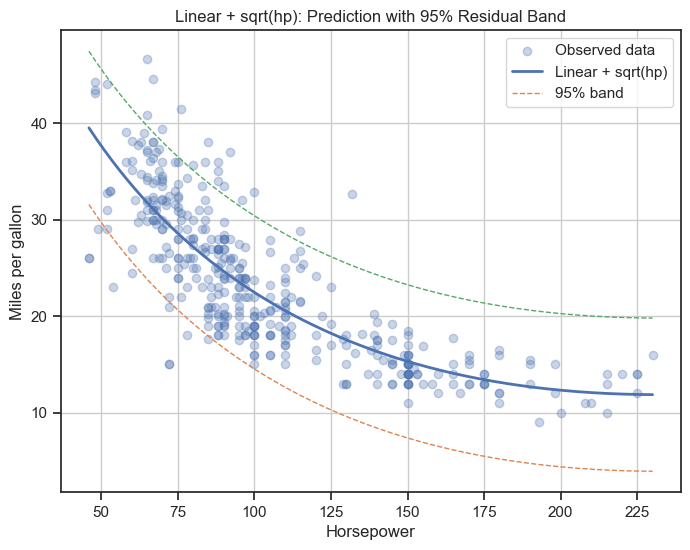

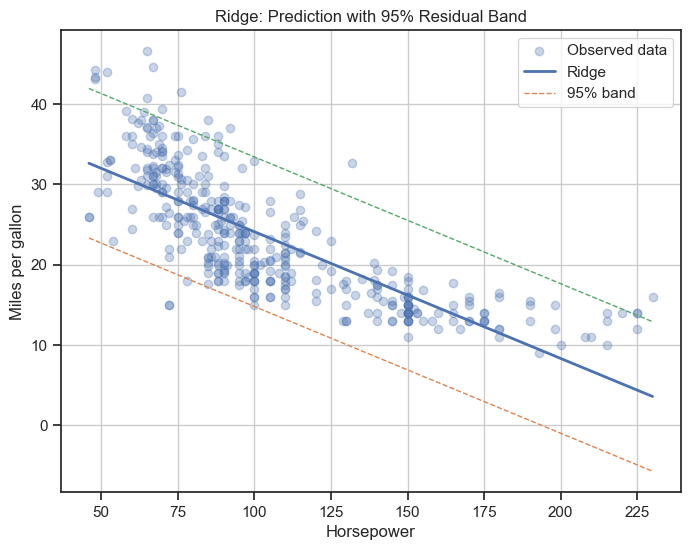

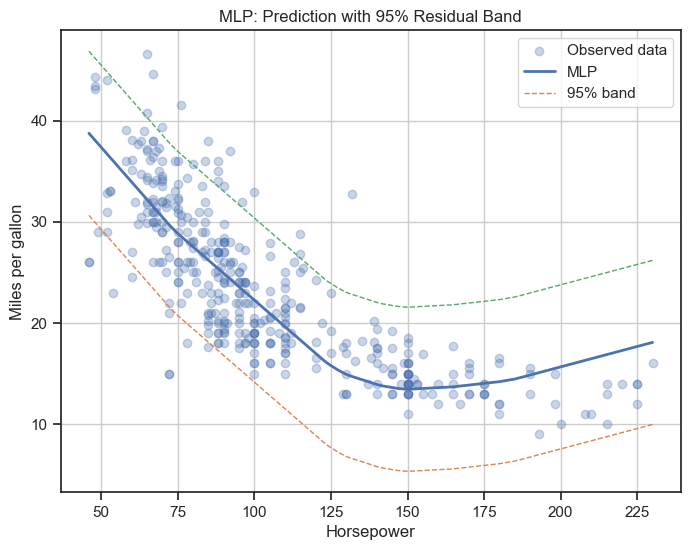

In [217]:
def plot_model_with_band(hp, mpg, hp_grid, y_curve, band, title, label):
    lower = y_curve - band
    upper = y_curve + band

    plt.figure(figsize=(8, 6))
    plt.scatter(hp, mpg, alpha=0.3, label="Observed data")
    plt.plot(hp_grid, y_curve, linewidth=2, label=label)
    plt.plot(hp_grid, lower, linestyle="--", linewidth=1, label="95% band")
    plt.plot(hp_grid, upper, linestyle="--", linewidth=1)
    plt.xlabel("Horsepower")
    plt.ylabel("Miles per gallon")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_model_with_band(hp, mpg, hp_grid, y_lin_curve, band_lin,
                     "Linear + sqrt(hp): Prediction with 95% Residual Band",
                     "Linear + sqrt(hp)")

plot_model_with_band(hp, mpg, hp_grid, y_ridge_curve, band_ridge,
                     "Ridge: Prediction with 95% Residual Band",
                     "Ridge")

plot_model_with_band(hp, mpg, hp_grid, y_mlp_curve, band_mlp,
                     "MLP: Prediction with 95% Residual Band",
                     "MLP")


## Multivariate Regression

In [344]:
features = [
    "horsepower",
    "weight_lbs",
    "displacement",
    "cylinders",
    "acceleration",
    "model_year",
    "origin_country",
]

X = dataset_automobile[features].to_numpy()
y = dataset_automobile["miles_per_gallon"].to_numpy()


In [345]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [346]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_multi = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_multi.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [347]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_ridge = ridge_multi.predict(X_test)

rmse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Multivariate Ridge RMSE:", rmse_ridge)
print("Multivariate Ridge R²:", r2_ridge)


Multivariate Ridge RMSE: 10.76738958337502
Multivariate Ridge R²: 0.7890425833738295


In [348]:
coefficients = ridge_multi.named_steps["model"].coef_

for feature, coef in zip(features, coefficients):
    print(f"{feature:15s} : {coef:.3f}")

horsepower      : -0.847
weight_lbs      : -4.983
displacement    : 1.345
cylinders       : -0.536
acceleration    : 0.070
model_year      : 2.762
origin_country  : 1.288


In [349]:
mlp_multi = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(50, 50),
        activation="relu",
        max_iter=10000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_multi.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_

In [350]:
y_pred_mlp = mlp_multi.predict(X_test)

rmse_mlp = mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("Multivariate MLP RMSE:", rmse_mlp)
print("Multivariate MLP R²:", r2_mlp)


Multivariate MLP RMSE: 9.119897196056685
Multivariate MLP R²: 0.8213206703928578


In [351]:
results = pd.DataFrame({
    "Model": ["Ridge (multivariate)", "MLP (multivariate)"],
    "RMSE": [rmse_ridge, rmse_mlp],
    "R²": [r2_ridge, r2_mlp]
})

results


,Model,RMSE,R²
0,Ridge (multivariate),10.767390,0.789043
1,MLP (multivariate),9.119897,0.821321


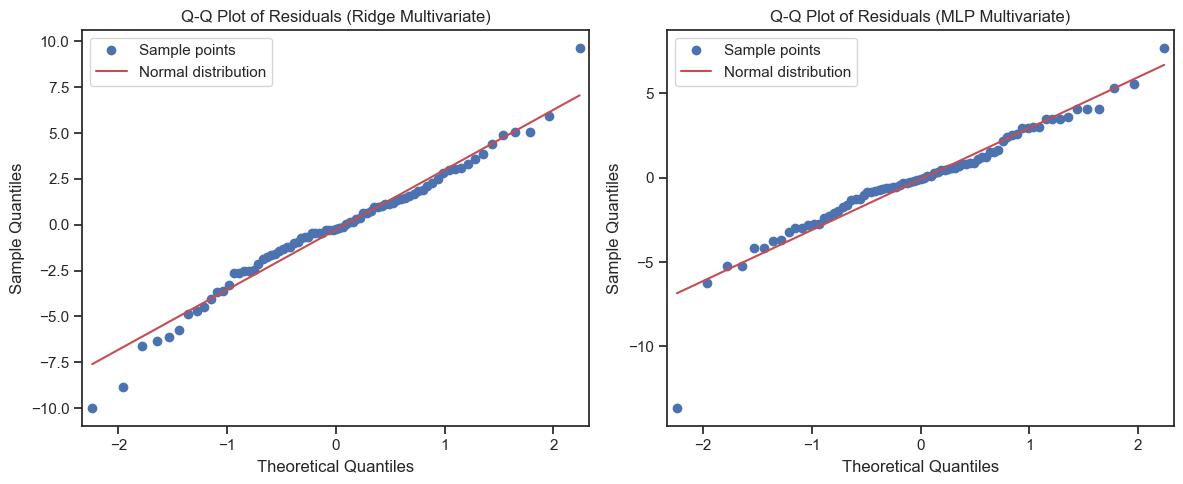

In [ ]:
residuals_ridge = y_test - y_pred_ridge
residuals_mlp = y_test - y_pred_mlp

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sm.qqplot(residuals_ridge, line="s", ax=axes[0])
axes[0].set_title("Q-Q Plot of Residuals (Ridge Multivariate)")
lines = axes[0].get_lines()
lines[0].set_label("Sample points")
lines[1].set_label("Normal distribution")
axes[0].legend()

sm.qqplot(residuals_mlp, line="s", ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals (MLP Multivariate)")
lines = axes[1].get_lines()
lines[0].set_label("Sample points")
lines[1].set_label("Normal distribution")
axes[1].legend()

plt.tight_layout()
plt.show()


In [440]:
stats.shapiro(residuals_ridge)

ShapiroResult(statistic=np.float64(0.9795078213841723), pvalue=np.float64(0.23441028210946524))

In [354]:
stats.shapiro(residuals_mlp)

ShapiroResult(statistic=np.float64(0.9403164574689298), pvalue=np.float64(0.0010881462014766476))

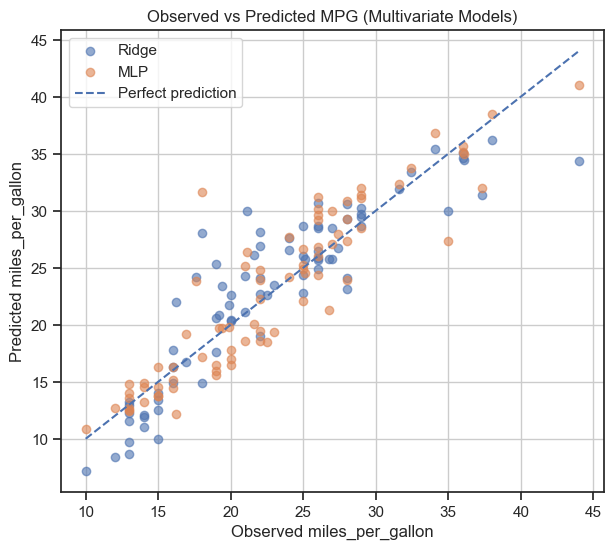

In [355]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.6,
    label="Ridge"
)

plt.scatter(
    y_test,
    y_pred_mlp,
    alpha=0.6,
    label="MLP"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Observed miles_per_gallon")
plt.ylabel("Predicted miles_per_gallon")
plt.title("Observed vs Predicted MPG (Multivariate Models)")
plt.legend()
plt.grid(True)
plt.show()


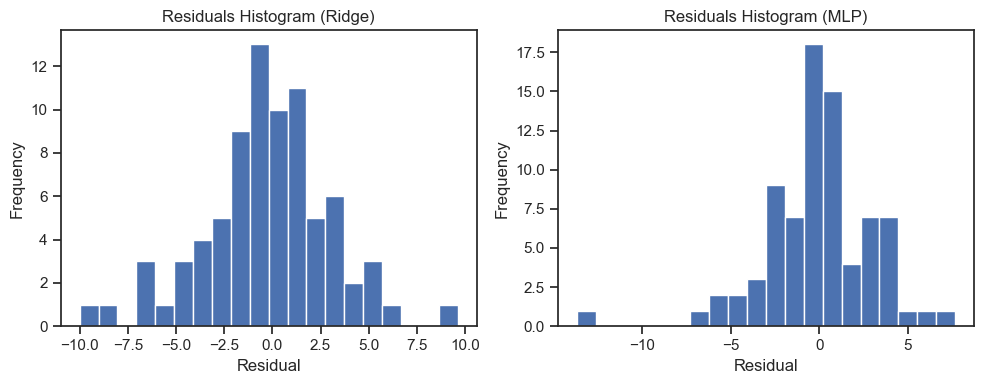

In [356]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals_ridge, bins=20)
plt.title("Residuals Histogram (Ridge)")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(residuals_mlp, bins=20)
plt.title("Residuals Histogram (MLP)")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## PCA

In [389]:
features_pca = [
    "horsepower",
    "weight_lbs",
    "displacement",
    "cylinders",
    "acceleration",
    "model_year",
    "origin_country",
]

X_pca = dataset_automobile[features_pca]


In [390]:
scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)


In [391]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca_transformed = pca.fit_transform(X_pca_scaled)

In [392]:
explained_variance = pca.explained_variance_ratio_

explained_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": np.cumsum(explained_variance)
})

explained_df


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.658866,0.658866
1,PC2,0.134290,0.793156
2,PC3,0.106309,0.899465
3,PC4,0.068759,0.968224
4,PC5,0.018510,0.986734
5,PC6,0.008451,0.995185
6,PC7,0.004815,1.000000


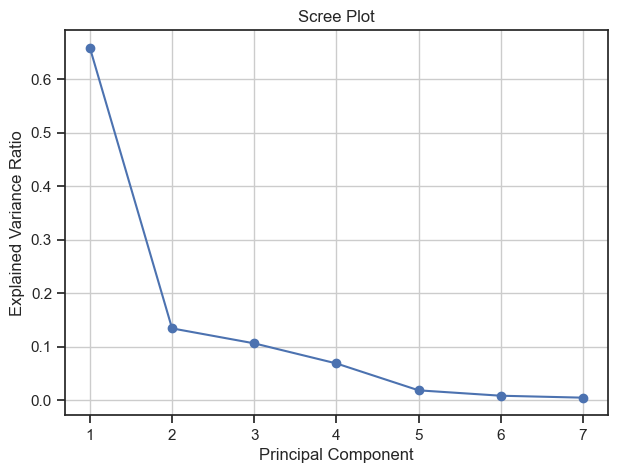

In [393]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()


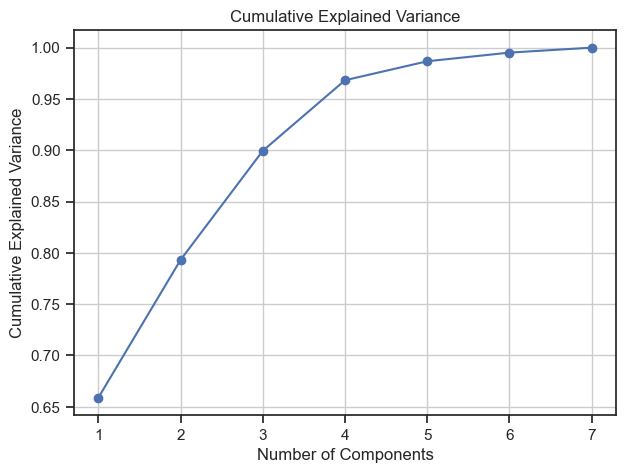

In [394]:
plt.figure(figsize=(7, 5))
plt.plot(
    range(1, len(explained_variance) + 1),
    np.cumsum(explained_variance),
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [395]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_pca_scaled)

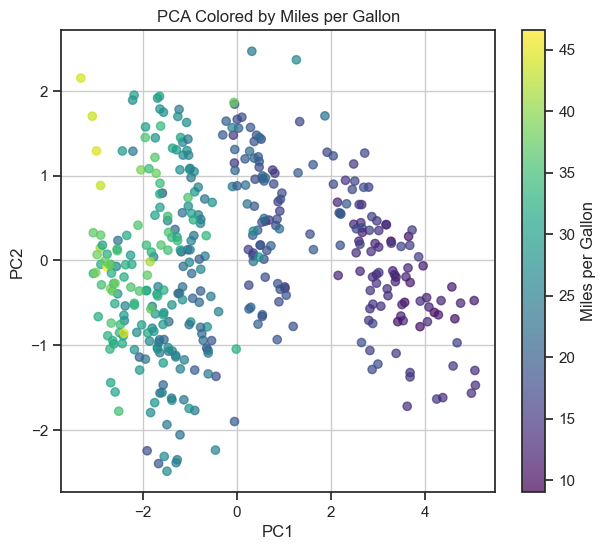

In [396]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=dataset_automobile["miles_per_gallon"],
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Colored by Miles per Gallon")
plt.colorbar(scatter, label="Miles per Gallon")
plt.grid(True)
plt.show()


In [397]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=features_pca
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
horsepower,0.437557,-0.142440,0.178506,0.124582,-0.579393,-0.613608,-0.169288
weight_lbs,0.431946,0.202775,-0.012594,0.335229,-0.348536,0.707768,-0.193274
displacement,0.453366,0.107443,0.022196,0.159331,0.176287,-0.063710,0.849647
cylinders,0.438118,0.120214,0.025530,0.240871,0.700160,-0.194831,-0.454695
acceleration,-0.297708,0.482186,-0.559064,0.527333,-0.120916,-0.270696,0.018386
model_year,-0.214733,0.642498,0.731845,0.028882,-0.024231,-0.063132,0.009091
origin_country,-0.299563,-0.517002,0.344505,0.713990,0.079480,0.057186,0.070128


## Regression with PCA

In [419]:
features = [
    "horsepower",
    "weight_lbs",
    "displacement",
    "cylinders",
    "acceleration",
    "model_year",
    "origin_country",
    
]

X = dataset_automobile[features].to_numpy()
y = dataset_automobile["miles_per_gallon"].to_numpy()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [421]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca_full = PCA()
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
cumulative_variance

array([0.65724365, 0.79344369, 0.89633334, 0.96796531, 0.98648899,
       0.99517489, 1.        ])

In [422]:
pca_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=3)),
    ("model", Ridge(alpha=1.0))
])

pca_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'fu

In [423]:
y_pred_pca_ridge = pca_ridge.predict(X_test)

rmse_pca_ridge = mean_squared_error(
    y_test, y_pred_pca_ridge
)
r2_pca_ridge = r2_score(y_test, y_pred_pca_ridge)

print("PCA + Ridge RMSE:", rmse_pca_ridge)
print("PCA + Ridge R²:", r2_pca_ridge)

PCA + Ridge RMSE: 12.999621175916102
PCA + Ridge R²: 0.7453081381373654


In [424]:
pca_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=3)),
    ("model", MLPRegressor(
        hidden_layer_sizes=(50, 50),
        max_iter=10000,
        early_stopping=True,
        random_state=42
    ))
])

pca_mlp.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'fu

In [425]:
y_pred_pca_mlp = pca_mlp.predict(X_test)

rmse_pca_mlp = mean_squared_error(
    y_test, y_pred_pca_mlp
)
r2_pca_mlp = r2_score(y_test, y_pred_pca_mlp)

print("PCA + MLP RMSE:", rmse_pca_mlp)
print("PCA + MLP R²:", r2_pca_mlp)

PCA + MLP RMSE: 8.175988799561365
PCA + MLP R²: 0.8398139621340478


In [426]:
results_pca = pd.DataFrame({
    "Model": [
        "Ridge (no PCA)",
        "MLP (no PCA)",
        "PCA + Ridge",
        "PCA + MLP"
    ],
    "RMSE": [
        rmse_ridge,
        rmse_mlp,
        rmse_pca_ridge,
        rmse_pca_mlp
    ],
    "R²": [
        r2_ridge,
        r2_mlp,
        r2_pca_ridge,
        r2_pca_mlp
    ]
})

results_pca

,Model,RMSE,R²
0,Ridge (no PCA),10.767390,0.789043
1,MLP (no PCA),9.119897,0.821321
2,PCA + Ridge,12.999621,0.745308
3,PCA + MLP,8.175989,0.839814


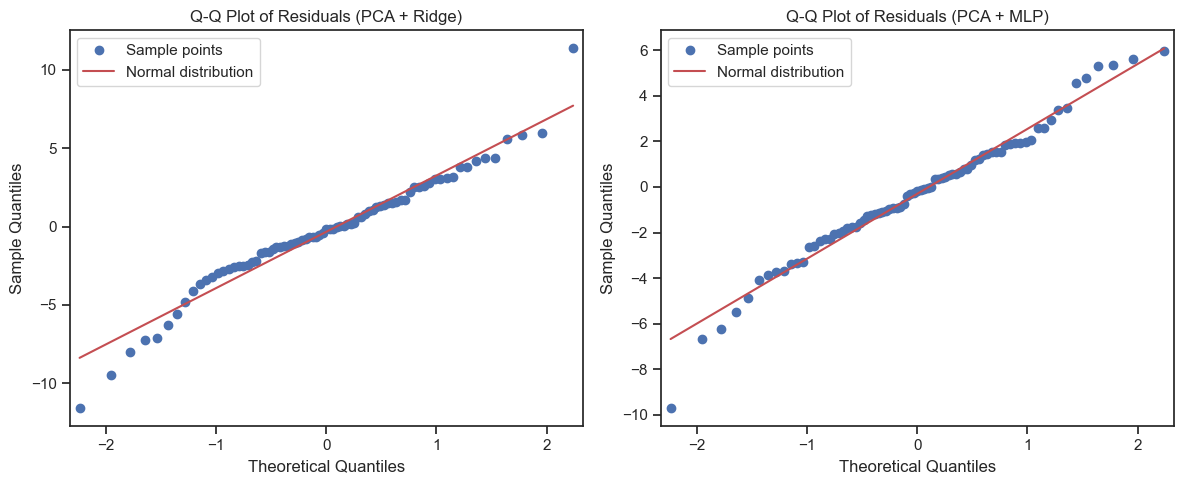

In [448]:
resid_pca_ridge = y_test - y_pred_pca_ridge
resid_pca_mlp = y_test - y_pred_pca_mlp

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sm.qqplot(resid_pca_ridge, line="s", ax=axes[0])
axes[0].set_title("Q-Q Plot of Residuals (PCA + Ridge)")
lines = axes[0].get_lines()
lines[0].set_label("Sample points")
lines[1].set_label("Normal distribution")
axes[0].legend()

sm.qqplot(resid_pca_mlp, line="s", ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals (PCA + MLP)")
lines = axes[1].get_lines()
lines[0].set_label("Sample points")
lines[1].set_label("Normal distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

In [428]:
stats.shapiro(resid_pca_ridge)

ShapiroResult(statistic=np.float64(0.968645355773784), pvalue=np.float64(0.048895698259701977))

In [429]:
stats.shapiro(resid_pca_mlp)

ShapiroResult(statistic=np.float64(0.981045546176184), pvalue=np.float64(0.2899245845684646))

# Clustering

In [430]:
features_cluster = [
    "horsepower",
    "weight_lbs",
    "displacement",
    "cylinders",
    "acceleration",
    "model_year",
    "origin_country",
]

X = dataset_automobile[features_cluster].to_numpy()


In [431]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [432]:
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


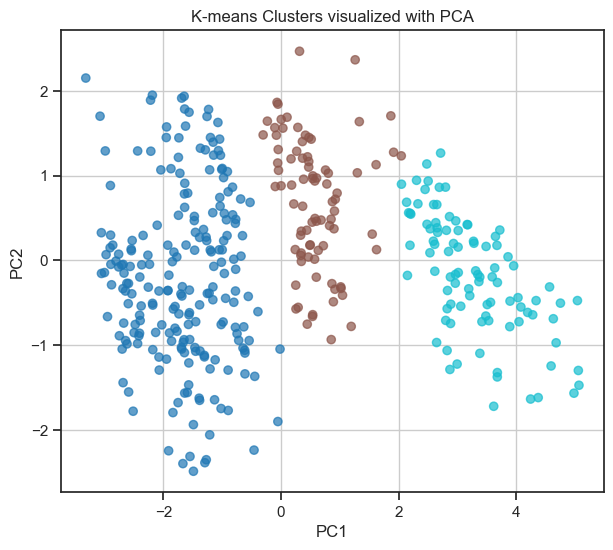

In [434]:
plt.figure(figsize=(7, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means Clusters visualized with PCA")
plt.grid(True)
plt.show()


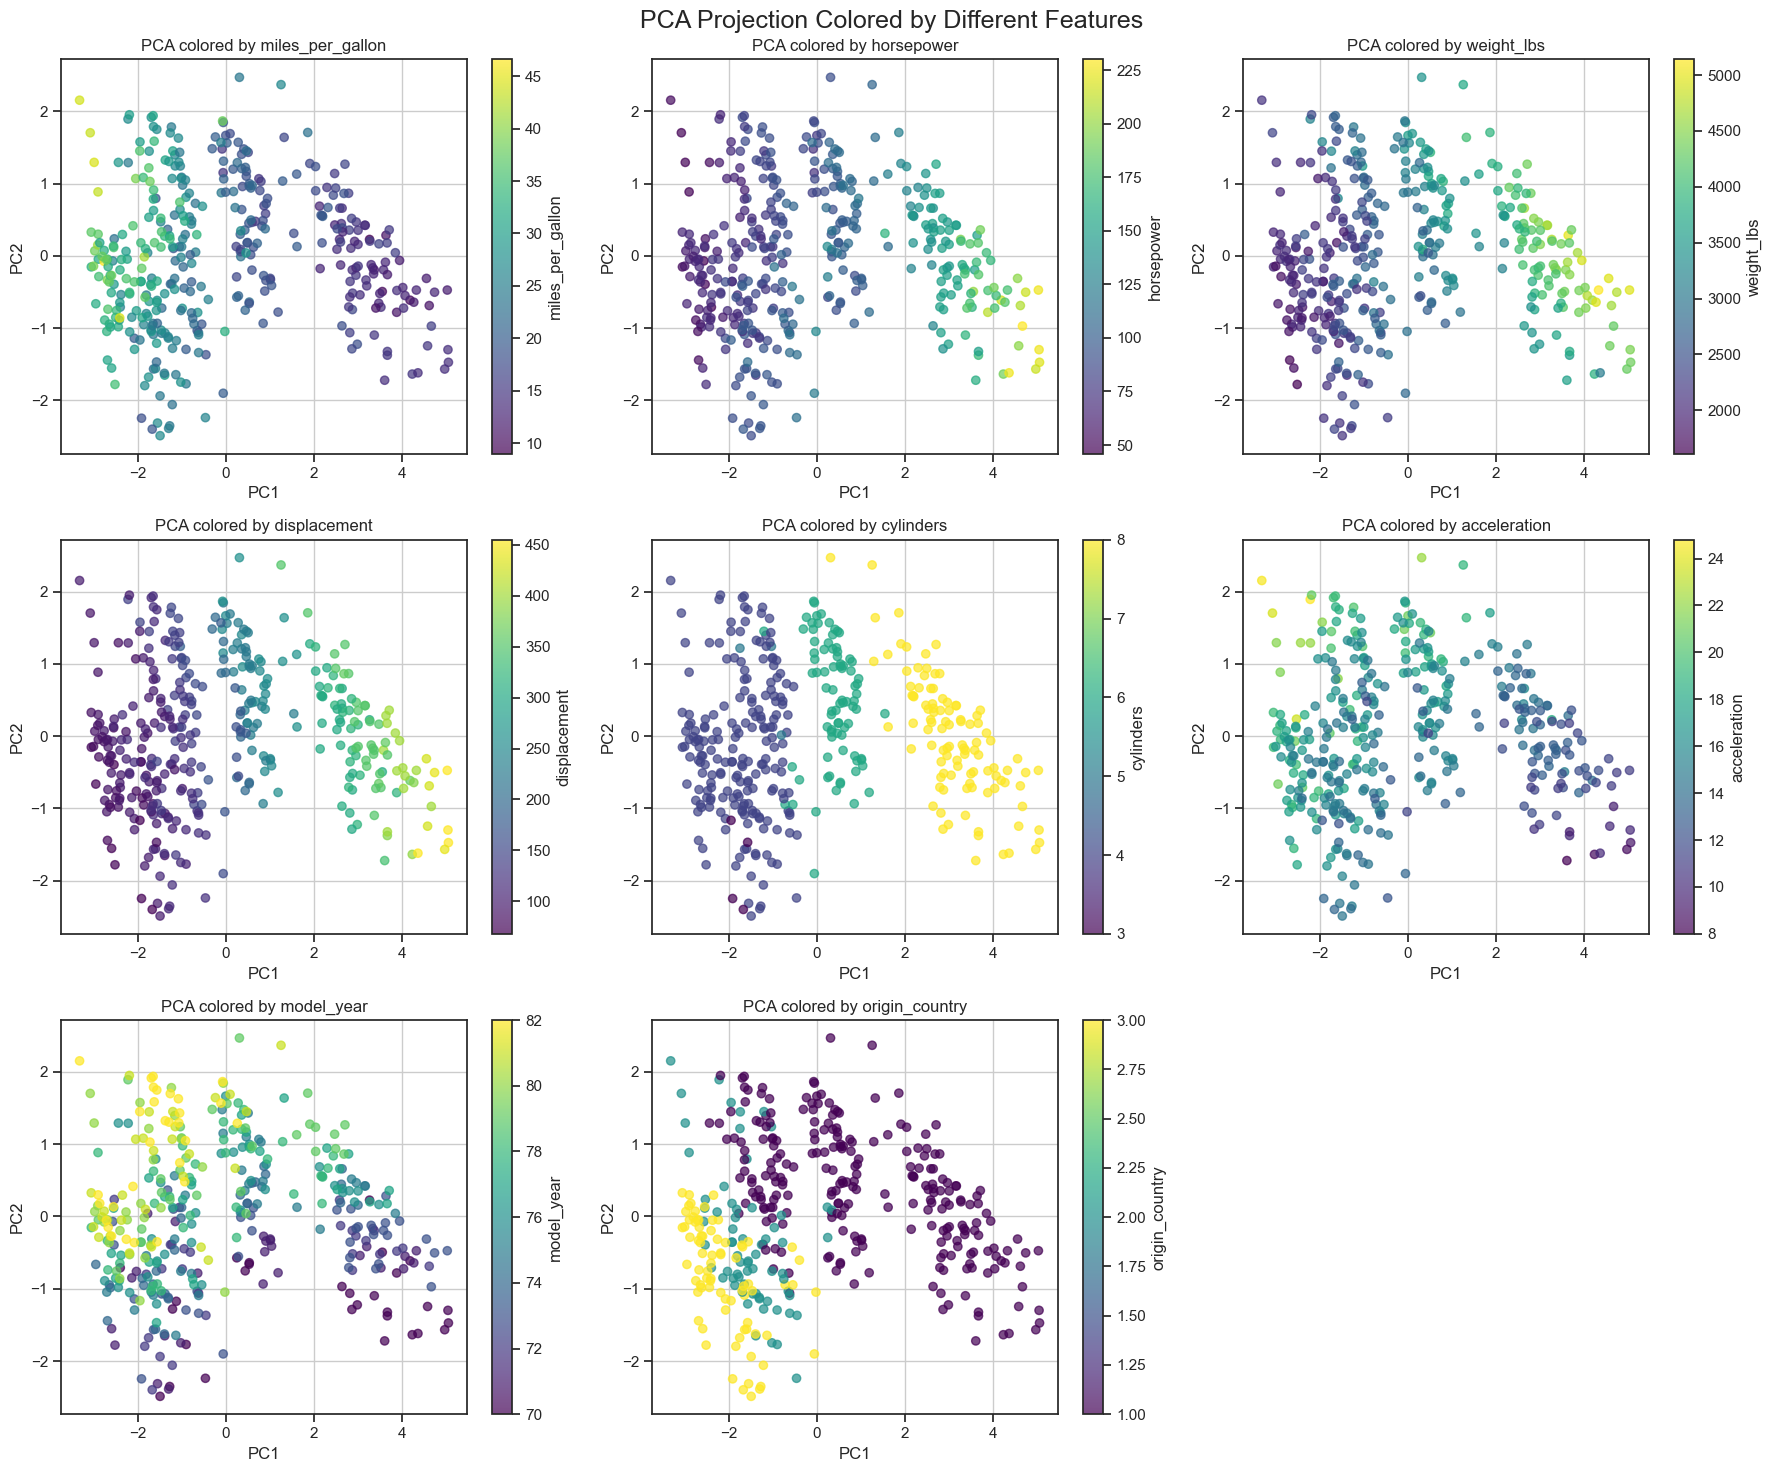

In [435]:
features_to_color = [
    "miles_per_gallon",
    "horsepower",
    "weight_lbs",
    "displacement",
    "cylinders",
    "acceleration",
    "model_year",
    "origin_country",
]

n_features = len(features_to_color)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(features_to_color):
    scatter = axes[i].scatter(
        X_pca_2[:, 0],
        X_pca_2[:, 1],
        c=dataset_automobile[feature],
        cmap="viridis",
        alpha=0.7
    )
    
    axes[i].set_title(f"PCA colored by {feature}")
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")
    axes[i].grid(True)
    
    cbar = fig.colorbar(scatter, ax=axes[i])
    cbar.set_label(feature)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("PCA Projection Colored by Different Features", fontsize=18)
plt.tight_layout()
plt.show()


In [436]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=0
)

X_umap = umap_model.fit_transform(X_scaled)


c:\Users\ZodiacV\Desktop\Data Analysis\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


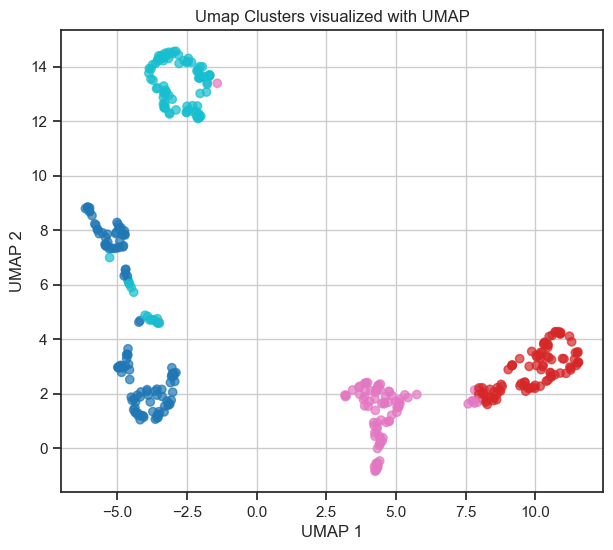

In [437]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=clusters,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Umap Clusters visualized with UMAP")
plt.grid(True)
plt.show()

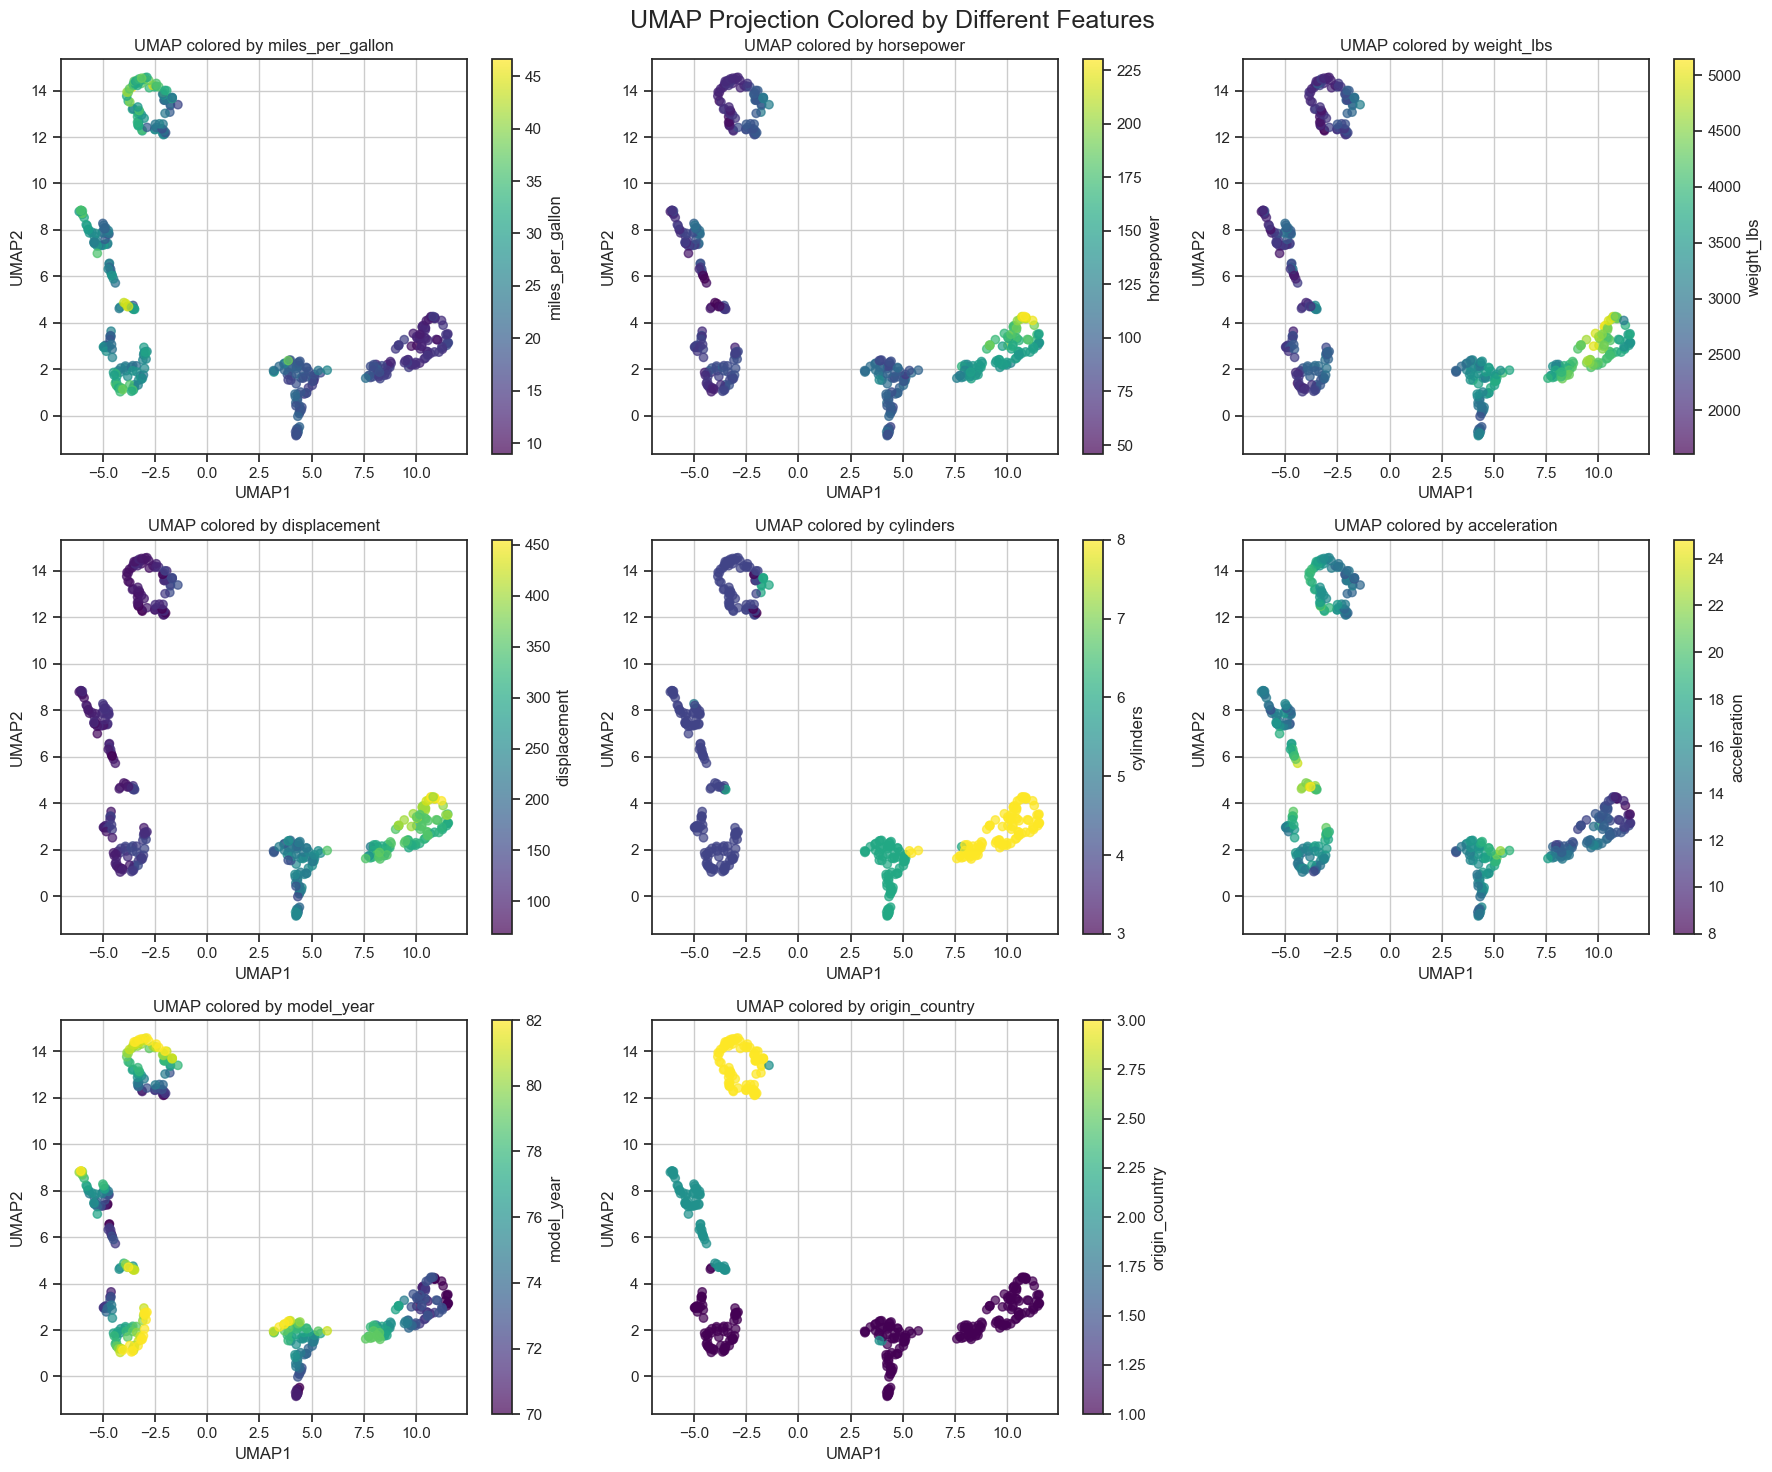

In [438]:
n_features = len(features_to_color)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(features_to_color):
    scatter = axes[i].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        c=dataset_automobile[feature],
        cmap="viridis",
        alpha=0.7
    )
    
    axes[i].set_title(f"UMAP colored by {feature}")
    axes[i].set_xlabel("UMAP1")
    axes[i].set_ylabel("UMAP2")
    axes[i].grid(True)
    
    cbar = fig.colorbar(scatter, ax=axes[i])
    cbar.set_label(feature)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("UMAP Projection Colored by Different Features", fontsize=18)
plt.tight_layout()
plt.show()
